<h1> German Articles Classifier </h1>
<p> In german language there are 3 types of articles (der - masculine, die - feminine, das - neutral)</p>
<p> Each noun has its article (it may seem strange, because in english there is no such thing)</p>
<p> On of the hardest aspects of learning german is remembering the articles, there are some patterns for it, but it is not that simple, in this project I will show whether a neural network can can classify the article of the noun by </p>
<p>- semantic meaning</p>
<p>- letters of the words</p>
<p>before starting, if you know german, how accurate do you think these models can get?</p> 

first the semantic meaning approach, we will download an embedding matrix (it contains a vector for each word corresponding to its meaning) from fasttext libary. It is trained on the german wikipedia

In [1]:
import fasttext
import fasttext.util
import os

if os.path.exists('cc.de.300.bin'):
    ft = fasttext.load_model('cc.de.300.bin')
else: 
    fasttext.util.download_model('de', if_exists='ignore')
    ft = fasttext.load_model('cc.de.300.bin')
ft.get_dimension()

300

In [3]:
print("total words:", len(ft.get_words()))

total words: 2000000


In [2]:
ft.get_words()[10000:10020]

['Wahnsinn',
 'übers',
 'konfrontiert',
 'natur',
 'Alters',
 'Posts',
 'Absolventen',
 'Au',
 'filtern',
 'Experiment',
 'Tante',
 'überwinden',
 'verpasste',
 'türkischer',
 '138',
 'weiblich',
 'Spalte',
 '1792',
 'Ice',
 'Kieler']

as we see, there are 2 mln words here. This is much more than in dictionaries because it also count specific dates, missspelled words etc. Lets see some synonyms of a word 'Kaiser'

In [14]:
synonym = ft.get_nearest_neighbors("Kaiser", k=3)
print(synonym)

[(0.7963113188743591, 'Kaisers'), (0.7051979899406433, 'König'), (0.6807593703269958, 'kaiser')]


We can also see the similarity of the 2 chosen words with some linear algebra

In [15]:
import numpy as np

def get_similarity(word1, word2, model):
  
    vec1 = model.get_word_vector(word1)
    vec2 = model.get_word_vector(word2)
    
    
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    similarity = dot_product / (norm_vec1 * norm_vec2)
    return similarity

score = get_similarity("Kaiser", "König", ft)
print(f"Similarity score between words: {score:.4f}")



Similarity score between words: 0.7052


Let's create another table with the words and their articles

In [16]:
import pandas as pd

In [17]:
nomen = pd.read_csv("mit_artikeln.csv")
nomen = nomen.rename(columns={"ihm": "Nomen", "none": "Artikel"})
nomen.head()

,Nomen,Artikel
0,koennen,none
1,ich,n
2,sie,none
3,das,none
4,ist,n


In [18]:
nomen.shape

(308596, 2)

we have to drop all the words which are not nouns, we see that most of the words have feminine article. It is correct with the german language. We have to make the words start with a capital letter (german quirk).

In [19]:
nomen = nomen[nomen['Artikel'] != "none"]
nomen.value_counts("Artikel")

Artikel
f    14367
m    11379
n     7886
Name: count, dtype: int64

In [20]:
nomen['Nomen'] = nomen['Nomen'].str.capitalize()
nomen.head()
nomen.dropna(inplace=True)

now we have our table with articles prepared, let's get only those embeddings where the word in our table exists

In [21]:
embeddings = []
for wort in nomen['Nomen']:
    vec = ft.get_word_vector(wort)
    embeddings.append(vec)

In [22]:
print(len(embeddings))
print(len(nomen))

33631
33631


In [23]:
N = len(nomen)

In [24]:
embeddings[0]

array([-2.28376482e-02, -2.98091583e-02,  2.75894962e-02,  4.97914031e-02,
       -7.77024776e-02, -2.56407261e-02, -2.99380720e-02, -1.34478197e-01,
       -3.67305800e-02,  3.75720859e-02,  4.44884747e-02, -8.40175152e-02,
       -2.30602510e-02,  2.75183879e-02,  3.14015672e-02, -1.06262788e-01,
       -5.45327365e-02, -1.00627869e-01,  3.49839255e-02, -1.16013184e-01,
       -6.31883368e-02,  5.27716428e-03, -6.81491047e-02,  5.33879846e-02,
       -9.67519283e-02,  3.35094705e-03, -2.12709785e-01, -1.98830068e-02,
        2.18218081e-02,  2.65565105e-02,  2.09372103e-01, -4.03613821e-02,
       -2.87825745e-02, -2.44163454e-01, -5.65734394e-02, -1.13122081e-02,
       -6.68301992e-03, -1.40202984e-01, -1.75220609e-01, -4.38507795e-02,
       -2.50050053e-03, -1.30704716e-01,  1.98687941e-01,  2.05967184e-02,
       -2.15421207e-02,  2.15674341e-01, -9.23006460e-02,  8.24503899e-02,
       -8.41995701e-03,  2.02306762e-01, -1.50643531e-02,  2.69654859e-03,
       -7.52547681e-02, -

In [25]:
nomen[2000:2005]


,Nomen,Artikel
5842,Boxen,n
5843,Angestellten,f
5845,Insgesamt,m
5846,Flecken,m
5853,Abbrechen,n


 we might not have to shuffle the data because the words that come first are the ones that are easier to learn (more people know the). This will simulate a learning person better

In [17]:
X = np.array(embeddings, dtype='float32')
y = nomen['Artikel'].values

In [18]:
mapping = {'f': 2, 'm': 1, 'n': 0}
y = np.array([mapping[artikel] for artikel in y])

In [19]:
y

array([0, 0, 0, ..., 2, 2, 2])

In [20]:
X_train = X[:10000]
y_train = y[:10000]
X_valid = X[10000:15000]
y_valid = y[10000:15000]
X_test = X[15000:]
y_test = y[15000:]


In [21]:
import tensorflow as tf

In [22]:
print("y_train type:", type(y_train[0]))    # Should be an int or float

y_train type: <class 'numpy.int32'>


In [23]:
artikel_guesser = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(300,)),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)
artikel_guesser.compile(optimizer=optimizer,
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy'])
artikel_guesser.summary()

    



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               77056     
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 128)               16512     
                                                                 
 batch_normalization_2 (Bat  (None, 128)               

In [24]:
history = artikel_guesser.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[early_stop])

Epoch 1/100


313/313 [==============================] - 5s 6ms/step - loss: 0.4546 - accuracy: 0.8429 - val_loss: 0.5581 - val_accuracy: 0.8746
Epoch 2/100
313/313 [==============================] - 1s 5ms/step - loss: 0.2478 - accuracy: 0.9184 - val_loss: 0.2149 - val_accuracy: 0.9390
Epoch 3/100
313/313 [==============================] - 1s 5ms/step - loss: 0.2112 - accuracy: 0.9281 - val_loss: 0.1897 - val_accuracy: 0.9436
Epoch 4/100
313/313 [==============================] - 1s 5ms/step - loss: 0.1807 - accuracy: 0.9375 - val_loss: 0.2071 - val_accuracy: 0.9384
Epoch 5/100
313/313 [==============================] - 1s 5ms/step - loss: 0.1664 - accuracy: 0.9418 - val_loss: 0.1890 - val_accuracy: 0.9410
Epoch 6/100
313/313 [==============================] - 1s 5ms/step - loss: 0.1508 - accuracy: 0.9458 - val_loss: 0.2087 - val_accuracy: 0.9352
Epoch 7/100
313/313 [==============================] - 1s 5ms/step - loss: 0.1380 - accuracy: 0.9523 - val_loss: 0.2111 - val_accuracy: 0.94

In [25]:
artikel_guesser.evaluate(X_test, y_test)

583/583 [==============================] - 1s 1ms/step - loss: 0.1621 - accuracy: 0.9501


[0.16211865842342377, 0.9501368403434753]

583/583 [==============================] - 1s 1ms/step


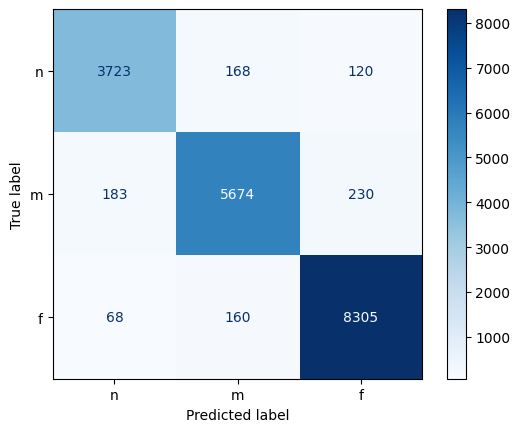

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = artikel_guesser.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['n', 'm', 'f'])
disp.plot(cmap=plt.cm.Blues)

In [27]:
vector = ft.get_word_vector("Mädchen")
artikel_guesser.predict(vector.reshape(1, -1))

1/1 [==============================] - 0s 32ms/step


array([[9.9703646e-01, 8.8992558e-04, 2.0737387e-03]], dtype=float32)

In [28]:
artikel_guesser.save("artikel_guesser_model2.h5", save_format="tf")

In [29]:
print(mapping)

{'f': 2, 'm': 1, 'n': 0}


In [30]:
reverse_mapping = {0 : 'Neutrum', 1 : 'Maskulinum', 2 : 'Femininum'}
dmapping = {0 : 'das', 1 : 'der', 2 : 'die'}
dmapping2 = {'n' : 'das', 'm' : 'der', 'f' : 'die'}

In [31]:

wort_vec = np.array(ft.get_word_vector('Katze'), dtype='float32')
#wort_vec = wort_vec.reshape(-1,1)
wort_vec.shape
wort_vec
np.string_

numpy.bytes_

In [32]:
X[0].shape

(300,)

In [33]:
def give_artikel(wort, model=artikel_guesser,mapping=dmapping,):
    wort_vec = np.array(ft.get_word_vector(wort), dtype='float32')
    wort_vec = wort_vec.reshape(1,-1)
    probas = model.predict(wort_vec)
    print(str(mapping[np.argmax(probas)]) + " " + wort)

def give_artikel_return(wort, model=artikel_guesser,mapping=dmapping,):
    wort_vec = np.array(ft.get_word_vector(wort), dtype='float32')
    wort_vec = wort_vec.reshape(1,-1)
    probas = model.predict(wort_vec)
    return str(mapping[np.argmax(probas)])
    

In [34]:
give_artikel('Katze')

1/1 [==============================] - 0s 24ms/step
die Katze


In [35]:
nomen.loc[nomen['Nomen'] == 'Katze'] #it is like SELECT * FROM nomen WHERE Nomen == 'Katze'

,Nomen,Artikel
1617,Katze,f


In [36]:
nomen.loc[nomen['Nomen'] == 'Katze']['Artikel'].values

array(['f'], dtype=object)

In [37]:
nomen.loc[nomen['Nomen'] == 'Katze']['Artikel'].iloc[0]

'f'

In [38]:
def true_artikel(wort, nomen=nomen, mapping=dmapping2):
    art = nomen.loc[nomen['Nomen'] == wort]['Artikel'].iloc[0]
    d = mapping[art]
    print(d + " " + wort)

def true_artikel_return(wort, nomen=nomen, mapping=dmapping2):
    art = nomen.loc[nomen['Nomen'] == wort]['Artikel'].iloc[0]
    d = mapping[art]
    return d

In [39]:
true_artikel('Katze')

die Katze


In [40]:
zahl = 50
worter = nomen['Nomen'].sample(zahl)
worter = worter.values
worter

array(['Stahlunternehmen', 'Plenarsitzung', 'Geschwisterpaar',
       'Familienzuwachs', 'Korrelation', 'Inselvolk', 'Bedingung',
       'Fluchten', 'Hefter', 'Filmverleih', 'Festungsgraben',
       'Italienerin', 'Notebook', 'Damenbesuch', 'Gesetz', 'Luftkissen',
       'Hasstirade', 'Sozialismus', 'Pflichtverteidiger', 'Unterhaltung',
       'Riesenschritt', 'Bedingungen', 'Gefolgsleute',
       'Vollstreckungsbefehl', 'Akzeptanz', 'Grundmauer', 'Wucht',
       'Nachwort', 'Span', 'Winden', 'Planer', 'Sicherheitsschaltung',
       'Stimmungswechsel', 'Landgericht', 'Versorgungsschiff', 'Umkreis',
       'Schuldbrief', 'Sporttauchen', 'Restbetrag', 'Ausschimpfen',
       'Hautkrebs', 'Lohn', 'Referenzierung', 'Lichtpause',
       'Abwassernetz', 'Prozessakten', 'Herzfrequenz', 'Annullierung',
       'Pfaffe', 'Stallmist'], dtype=object)

In [41]:
def Ergebnis(worter):
    for w in worter:
        print("vorausgesagt Ergebnis: ")
        give_artikel(w)
        print("richtige Ergebnis:")
        true_artikel(w)
        print()
        
        

In [42]:
Ergebnis(worter)

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 25ms/step
das Stahlunternehmen
richtige Ergebnis:
das Stahlunternehmen

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 22ms/step
die Plenarsitzung
richtige Ergebnis:
die Plenarsitzung

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 23ms/step
das Geschwisterpaar
richtige Ergebnis:
das Geschwisterpaar

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 22ms/step
der Familienzuwachs
richtige Ergebnis:
der Familienzuwachs

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 22ms/step
die Korrelation
richtige Ergebnis:
die Korrelation

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 21ms/step
das Inselvolk
richtige Ergebnis:
das Inselvolk

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 24ms/step
die Bedingung
richtige Ergebnis:
die Bedingung

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 24ms/step
die Fl

In [43]:
MAXLEN = 10

In [44]:
def word_prep(w, MAXLEN):
    w = w.lower()
    r = []
    n = min(len(w), MAXLEN)
    for i in range(-1, -n-1,-1):
        r.append(w[i])
    if(n < MAXLEN):
        for i in range(MAXLEN-n):
            r.append('0')
    print(r)
    
    


In [45]:
wp = word_prep('Sigmat', MAXLEN)
print(wp)

['t', 'a', 'm', 'g', 'i', 's', '0', '0', '0', '0']
None


In [46]:
categories = ['a','b'	,'c',	'd',	'e',	'f',	'g',	'h'	,'i',	'j',	'k',	'l',	'm',	'n',	'o',	'p',	'q',	'r',	's',	't',	'u',	'v',	'w',	'x',	'y',	'z'	,'ä'	,'ö'	,'ü',	'ß', '0']

In [47]:
MAXLEN = 10

categories = ['a','b'	,'c',	'd',	'e',	'f',	'g',	'h'	,'i',	'j',	'k',	'l',	'm',
              	'n',	'o',	'p',	'q',	'r',	's',	't',	'u',	'v',	'w',
                    	'x',	'y',	'z'	,'ä'	,'ö'	,'ü',	'ß', '0']
def word_prep(w, MAXLEN):
    w = w.lower()
    r = []
    n = min(len(w), MAXLEN)
    for i in range(-1, -n-1,-1):
        r.append(w[i])
    if(n < MAXLEN):
        for i in range(MAXLEN-n):
            r.append('0')
    return r

def onehot(cat):
    n = len(cat)
    oh = []
    for i in range(n):
        vec = [0] * n
        vec[i] = 1
        oh.append(vec)
    oh.append([0]*n)
    return oh

OneHot = onehot(categories)
hot_mapping = dict(zip(categories, OneHot))

In [48]:
[hot_mapping[letter] for letter in ['a','b','v']]

[[1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]]

In [49]:
def hotX(w,MAXLEN):
    r = word_prep(w,MAXLEN)
    HX = [hot_mapping[letter] for letter in r]
    flatHX = [item for sublist in HX for item in sublist] #flatten the list of lists into a vector
    return np.array(flatHX, dtype='int8')

In [50]:
X2 = nomen['Nomen'].values

In [51]:
X2 = [hotX(w, MAXLEN) for w in X2]

In [52]:
X2 = np.stack(X2)

In [53]:
X2.shape
X2_train = X2[:10000]
X2_valid= X2[10000:15000]
X2_test = X2[15000:]

In [54]:
kat = hotX('Kad', MAXLEN)

In [55]:
print(len(kat))

310


In [56]:
artikel_guesser2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(310,)),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)
artikel_guesser2.compile(optimizer=optimizer,
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy'])
artikel_guesser2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 256)               79616     
                                                                 
 batch_normalization_4 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_5 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_7 (Dense)             (None, 128)               16512     
                                                                 
 batch_normalization_6 (Bat  (None, 128)              

In [57]:
historyL = artikel_guesser2.fit(X2_train, y_train, epochs=100, validation_data=(X2_valid, y_valid), callbacks=[early_stop])

Epoch 1/100
313/313 [==============================] - 5s 7ms/step - loss: 0.9871 - accuracy: 0.5885 - val_loss: 0.7588 - val_accuracy: 0.6894
Epoch 2/100
313/313 [==============================] - 2s 6ms/step - loss: 0.7287 - accuracy: 0.6987 - val_loss: 0.6237 - val_accuracy: 0.7414
Epoch 3/100
313/313 [==============================] - 2s 5ms/step - loss: 0.6490 - accuracy: 0.7371 - val_loss: 0.5977 - val_accuracy: 0.7590
Epoch 4/100
313/313 [==============================] - 2s 5ms/step - loss: 0.5927 - accuracy: 0.7618 - val_loss: 0.5830 - val_accuracy: 0.7704
Epoch 5/100
313/313 [==============================] - 2s 5ms/step - loss: 0.5507 - accuracy: 0.7766 - val_loss: 0.5707 - val_accuracy: 0.7726
Epoch 6/100
313/313 [==============================] - 2s 5ms/step - loss: 0.5087 - accuracy: 0.7953 - val_loss: 0.5835 - val_accuracy: 0.7772
Epoch 7/100
313/313 [==============================] - 2s 5ms/step - loss: 0.4784 - accuracy: 0.8124 - val_loss: 0.5859 - val_accuracy: 0.7828

In [63]:
artikel_guesser2.evaluate(X2_test, y_test)

583/583 [==============================] - 1s 1ms/step - loss: 0.5215 - accuracy: 0.7983


[0.5214604139328003, 0.7983468174934387]

In [59]:
print(hotX("Haus", MAXLEN).shape)

(310,)


In [60]:
def give_artikel2_return(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    return str(mapping[np.argmax(probas)])

def give_artikel2(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    print(str(mapping[np.argmax(probas)]) + " " + wort)

def Ergebnis2(worter):
    for w in worter:
        print("vorausgesagt Ergebnis: ")
        give_artikel2(w, model=artikel_guesser2)
        print("richtige Ergebnis:")
        true_artikel(w)
        print()

In [69]:
zahl = 50
worter = nomen['Nomen'].sample(zahl)
worter = worter.values
Ergebnis2(worter)

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 23ms/step
die Demokratie
richtige Ergebnis:
der Demokratie

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 24ms/step
der Froschmann
richtige Ergebnis:
der Froschmann

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 36ms/step
die Devise
richtige Ergebnis:
die Devise

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 22ms/step
die Bescherung
richtige Ergebnis:
die Bescherung

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 22ms/step
das Referendum
richtige Ergebnis:
das Referendum

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 22ms/step
die Gute
richtige Ergebnis:
das Gute

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 26ms/step
der Fens
richtige Ergebnis:
der Fens

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 25ms/step
der Beschiss
richtige Ergebnis:
der Beschiss

vorausgesagt Ergebnis: 
1/1 

In [ ]:
Ergebnis2([''])

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 27ms/step
das Zimmer
richtige Ergebnis:
das Zimmer



In [94]:
print(give_artikel2_return('Joghurt'))

1/1 [==============================] - 0s 32ms/step
die
